## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [11]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv')
df = df.drop('total_litres_of_pure_alcohol', axis=1)
df = df.melt(id_vars='country', var_name='drink', value_name='servings')
df.head()

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

most beer:  Namibia
most wine: France
most spirits: Grenada


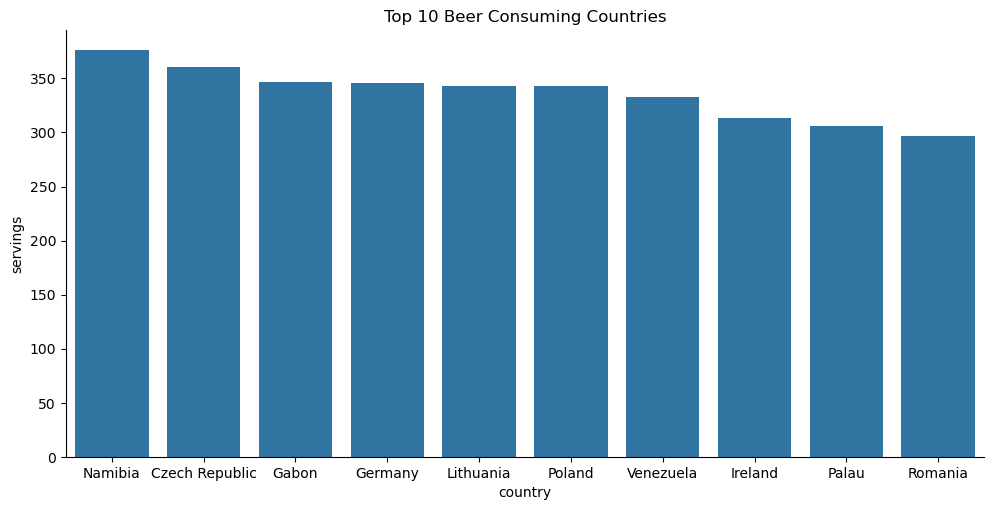

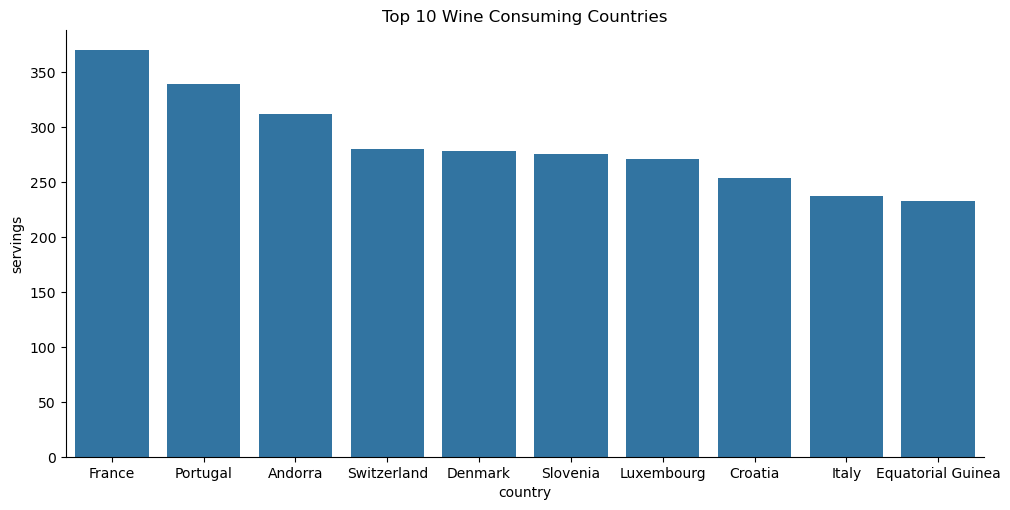

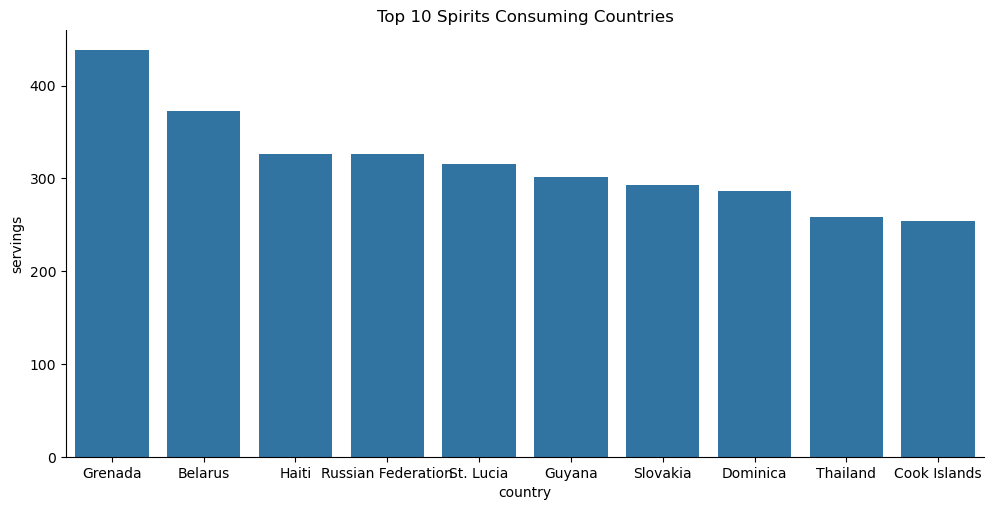

In [ ]:
import seaborn as sns

# remove _servings
df['drink'] = df['drink'].apply(lambda x: x.replace('_servings', ''))
df.head()

# which countries drink the most beer, wine, and spirits, respectively?
print('most beer: ', df.loc[df[df['drink'] == 'beer']['servings'].idxmax()]['country'])
print('most wine:', df.loc[df[df['drink'] == 'wine']['servings'].idxmax()]['country'])
print('most spirits:', df.loc[df[df['drink'] == 'spirit']['servings'].idxmax()]['country'])

top_ten_beers_df = df[df['drink'] == 'beer'].sort_values('servings', ascending=False).iloc[0:10]
top_ten_wines_df = df[df['drink'] == 'wine'].sort_values('servings', ascending=False).iloc[0:10]
top_ten_spirits_df = df[df['drink'] == 'spirit'].sort_values('servings', ascending=False).iloc[0:10]

# categorical plots
g = sns.catplot(data=top_ten_beers_df, kind='bar', x='country', y='servings', aspect=2)
g.set(title='Top 10 Beer Consuming Countries')

g = sns.catplot(data=top_ten_wines_df, kind='bar', x='country', y='servings', aspect=2)
g.set(title='Top 10 Wine Consuming Countries')

g = sns.catplot(data=top_ten_spirits_df, kind='bar', x='country', y='servings', aspect=2)
g.set(title='Top 10 Spirits Consuming Countries')

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [33]:
wide_df = pd.pivot_table(df, values='servings', index='country', columns='drink')
wide_df.head()

drink,beer,spirit,wine
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,132.0,54.0
Algeria,25.0,0.0,14.0
Andorra,245.0,138.0,312.0
Angola,217.0,57.0,45.0
